### BCB Data - EDA

Series:
- cdi daily (12)
- ipca monthly (433)
- tr daily (226)
- selic target (432)
- selic daily (11)

In [1]:
import sys
sys.path.insert(0, "..")

from datetime import date, timedelta
from src.ingestion.bcb import fetch_all

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.grid': False
})

#### Fetch

In [2]:
END = date.today()
START = END - timedelta(days=365 * 5) # Five years

data = fetch_all(start_date=START, end_date=END)


2026-05-26 08:01:06,996 [INFO] Fetching series 12 | 2021-05-27 → 2026-05-26 (attempt 1)
2026-05-26 08:01:27,706 [INFO] Series 12: 1253 records fetched.
2026-05-26 08:01:27,710 [INFO] Fetching series 433 | 2021-05-27 → 2026-05-26 (attempt 1)
2026-05-26 08:01:28,778 [INFO] Series 433: 60 records fetched.
2026-05-26 08:01:28,781 [INFO] Fetching series 226 | 2021-05-27 → 2026-05-26 (attempt 1)
2026-05-26 08:01:41,861 [INFO] Series 226: 1856 records fetched.
2026-05-26 08:01:41,865 [INFO] Fetching series 432 | 2021-05-27 → 2026-05-26 (attempt 1)
2026-05-26 08:01:42,184 [INFO] Series 432: 1826 records fetched.
2026-05-26 08:01:42,188 [INFO] Fetching series 11 | 2021-05-27 → 2026-05-26 (attempt 1)
2026-05-26 08:01:42,835 [INFO] Series 11: 1254 records fetched.


In [30]:
for name, df in data.items():
    n_invalid = (~df['is_valid']).sum()
    print(f"{name:13s} | {len(df):5d} rows | {n_invalid} invalid | from {df['date'].min().date()} to {df['date'].max().date()}")

cdi_daily     |  1253 rows | 0 invalid | from 2021-05-27 to 2026-05-22
ipca_monthly  |    60 rows | 0 invalid | from 2021-05-01 to 2026-04-01
tr_daily      |  1856 rows | 0 invalid | from 2021-05-27 to 2026-05-22
selic_target  |  1826 rows | 0 invalid | from 2021-05-27 to 2026-05-26
selic_daily   |  1254 rows | 0 invalid | from 2021-05-27 to 2026-05-25


#### Descriptive statistics

In [31]:
stats = (
    pd.concat(
        [df.assign(series=name) for name , df in data.items()]
    )
    .groupby('series')['value']
    .describe()
    .round(4)
)
display(stats)

,count,mean,std,min,25%,50%,75%,max
series,,,,,,,,
cdi_daily,1253.0,0.0449,0.0102,0.0133,0.0402,0.049,0.0508,0.0551
ipca_monthly,60.0,0.4828,0.4082,-0.6800,0.2400,0.465,0.7025,1.6200
selic_daily,1254.0,0.0449,0.0102,0.0133,0.0402,0.049,0.0508,0.0551
selic_target,1826.0,12.1366,2.8164,3.5000,10.7500,13.250,13.7500,15.0000
tr_daily,1856.0,0.1175,0.0658,0.0000,0.0708,0.128,0.1721,0.2443


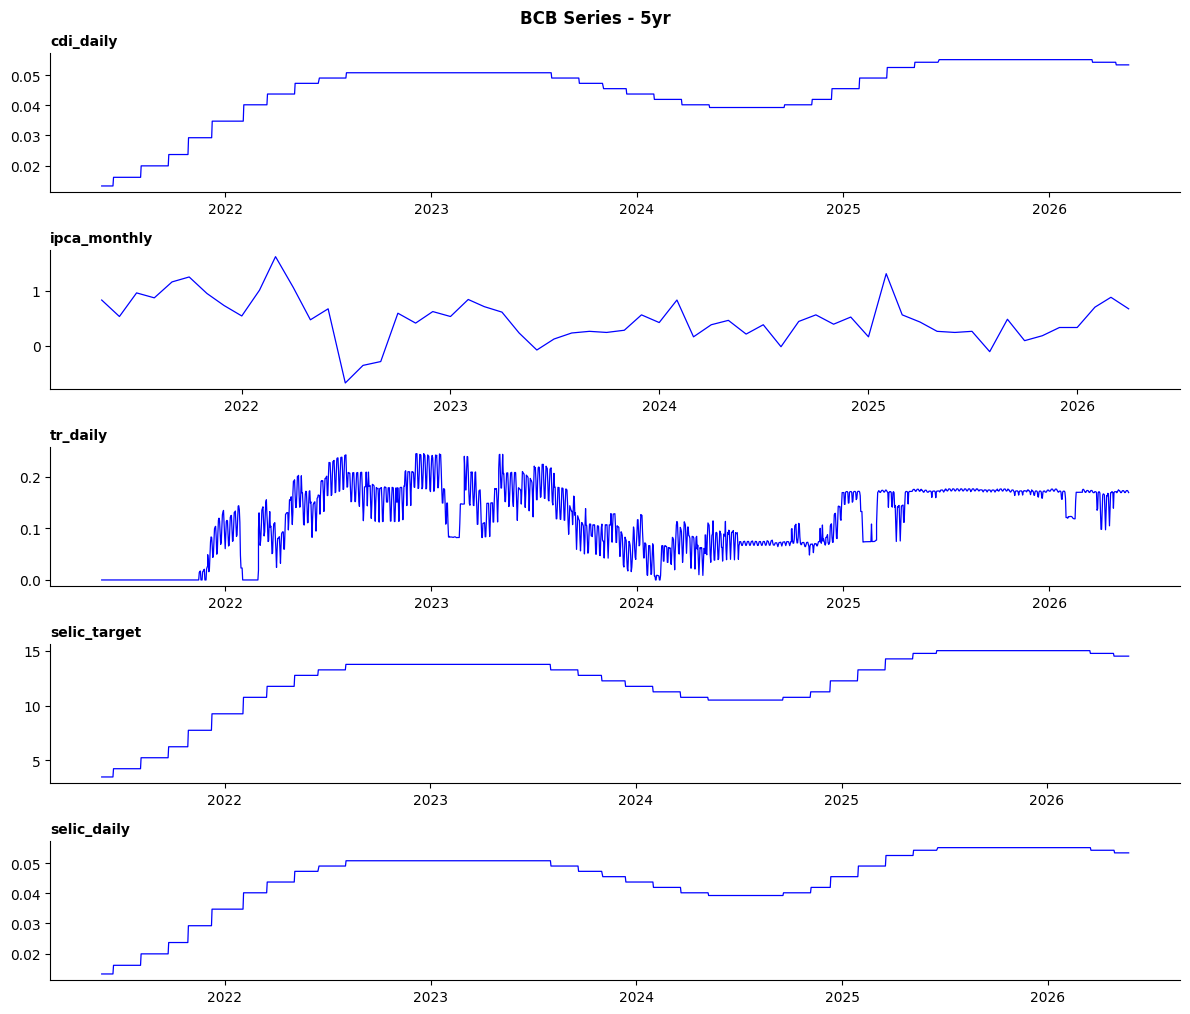

In [40]:
fig, axes = plt.subplots(len(data), 1, figsize=(12, 2 * len(data)), sharex=False)

colors = ['lightblue', 'blue', 'darkblue', 'lightblue', 'blue']

for ax, (name, df), color in zip(axes, data.items(), colors):
    valid = df[df['is_valid']]
    ax.plot(valid['date'], valid['value'], color='blue', linewidth=0.9, label=name)
    ax.set_title(name, fontsize=10, fontweight='bold', loc='left')
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    #ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.suptitle('BCB Series - 5yr', y=1.01, fontsize=12, fontweight='bold')
#plt.savefig('bcb_series.png', bbox_inches='tight')
plt.show()  


#### CDI vs SELIC
Looking for spread on CDI x SELIC overnight

In [ ]:
cdi = data['cdi_daily'][['date','value']].rename(columns={'value': 'cdi'})
selic = data['selic_daily'][['date','value']].rename(columns={'value': 'selic'})

merged = cdi.merge(selic, on ='date', how='inner')
merged['spread_bps'] = (merged['cdi'] - merged['selic'])

merged['spread_bps'].describe()

#### IPCA

Annualized and compared with SELIC/cdi

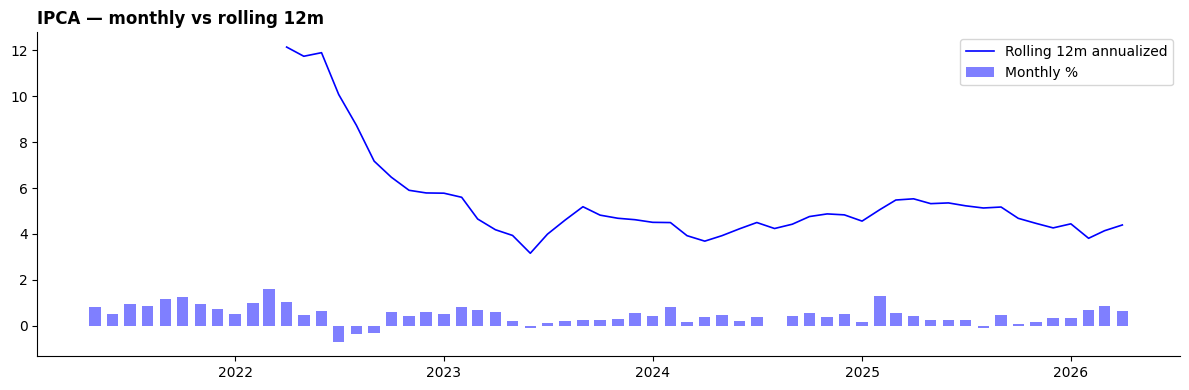

In [67]:
ipca = data['ipca_monthly'][['date','value']].copy()
ipca['value_annual'] = ((1+ ipca['value'] / 100) ** 12 -1 ) * 100

# rolling 12 months realized inflation
ipca = ipca.sort_values('date').reset_index(drop=True)
ipca['rolling_12m'] = (
    (1 + ipca['value'] / 100)
    .rolling(12)
    .apply(lambda x:x.prod(), raw=True) - 1
) * 100

fig, ax = plt.subplots(figsize=(12,4))
ax.bar(ipca['date'], ipca['value'], width=20, color='blue', alpha=0.5, label='Monthly %')
ax.plot(ipca['date'], ipca['rolling_12m'], color='blue', linewidth=1.2, label='Rolling 12m annualized')
ax.set_title('IPCA — monthly vs rolling 12m', loc='left', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()